<a href="https://colab.research.google.com/github/ranayasser108-debug/Machine-Learning-Projects/blob/main/housing1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

/tmp/ipykernel_833/2767306022.py:5: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

In [4]:
from google.colab import files
uploaded = files.upload()

Saving HousingData.csv to HousingData.csv


In [5]:
df = pd.read_csv("HousingData.csv")

In [6]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [7]:
df.shape

(506, 14)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [10]:
desc = pd.DataFrame(index=df.columns)

desc["Type"] = df.dtypes
desc["Count"] = df.count()
desc["Unique"] = df.nunique()
desc["%Unique"] = (desc["Unique"] / len(df)) * 100
desc["Null"] = df.isnull().sum()
desc["%Null"] = (desc["Null"] / len(df)) * 100

num_cols = df.select_dtypes(include=np.number).columns

desc["Min"] = df[num_cols].min()
desc["Max"] = df[num_cols].max()
desc["Mean"] = df[num_cols].mean()
desc["Median"] = df[num_cols].median()
desc["Std"] = df[num_cols].std()

desc

,Type,Count,Unique,%Unique,Null,%Null,Min,Max,Mean,Median,Std
CRIM,float64,486,484,95.652174,20,3.952569,0.00632,88.9762,3.611874,0.253715,8.720192
ZN,float64,486,26,5.138340,20,3.952569,0.00000,100.0000,11.211934,0.000000,23.388876
INDUS,float64,486,76,15.019763,20,3.952569,0.46000,27.7400,11.083992,9.690000,6.835896
CHAS,float64,486,2,0.395257,20,3.952569,0.00000,1.0000,0.069959,0.000000,0.255340
NOX,float64,506,81,16.007905,0,0.000000,0.38500,0.8710,0.554695,0.538000,0.115878
RM,float64,506,446,88.142292,0,0.000000,3.56100,8.7800,6.284634,6.208500,0.702617
AGE,float64,486,348,68.774704,20,3.952569,2.90000,100.0000,68.518519,76.800000,27.999513
DIS,float64,506,412,81.422925,0,0.000000,1.12960,12.1265,3.795043,3.207450,2.105710
RAD,int64,506,9,1.778656,0,0.000000,1.00000,24.0000,9.549407,5.000000,8.707259
TAX,int64,506,66,13.043478,0,0.000000,187.00000,711.0000,408.237154,330.000000,168.537116


In [12]:
print(df.isnull().sum())

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


In [13]:
print("\nPercentage of Missing Values:\n")
print((df.isnull().sum() / len(df)) * 100)


Percentage of Missing Values:

CRIM       3.952569
ZN         3.952569
INDUS      3.952569
CHAS       3.952569
NOX        0.000000
RM         0.000000
AGE        3.952569
DIS        0.000000
RAD        0.000000
TAX        0.000000
PTRATIO    0.000000
B          0.000000
LSTAT      3.952569
MEDV       0.000000
dtype: float64


In [14]:
import plotly.express as px

missing = df.isnull().sum().reset_index()
missing.columns = ["Column", "Missing Values"]

fig = px.bar(
    missing,
    x="Column",
    y="Missing Values",
    color="Missing Values",
    title="Missing Values in Housing Dataset",
    text="Missing Values"
)

fig.show()

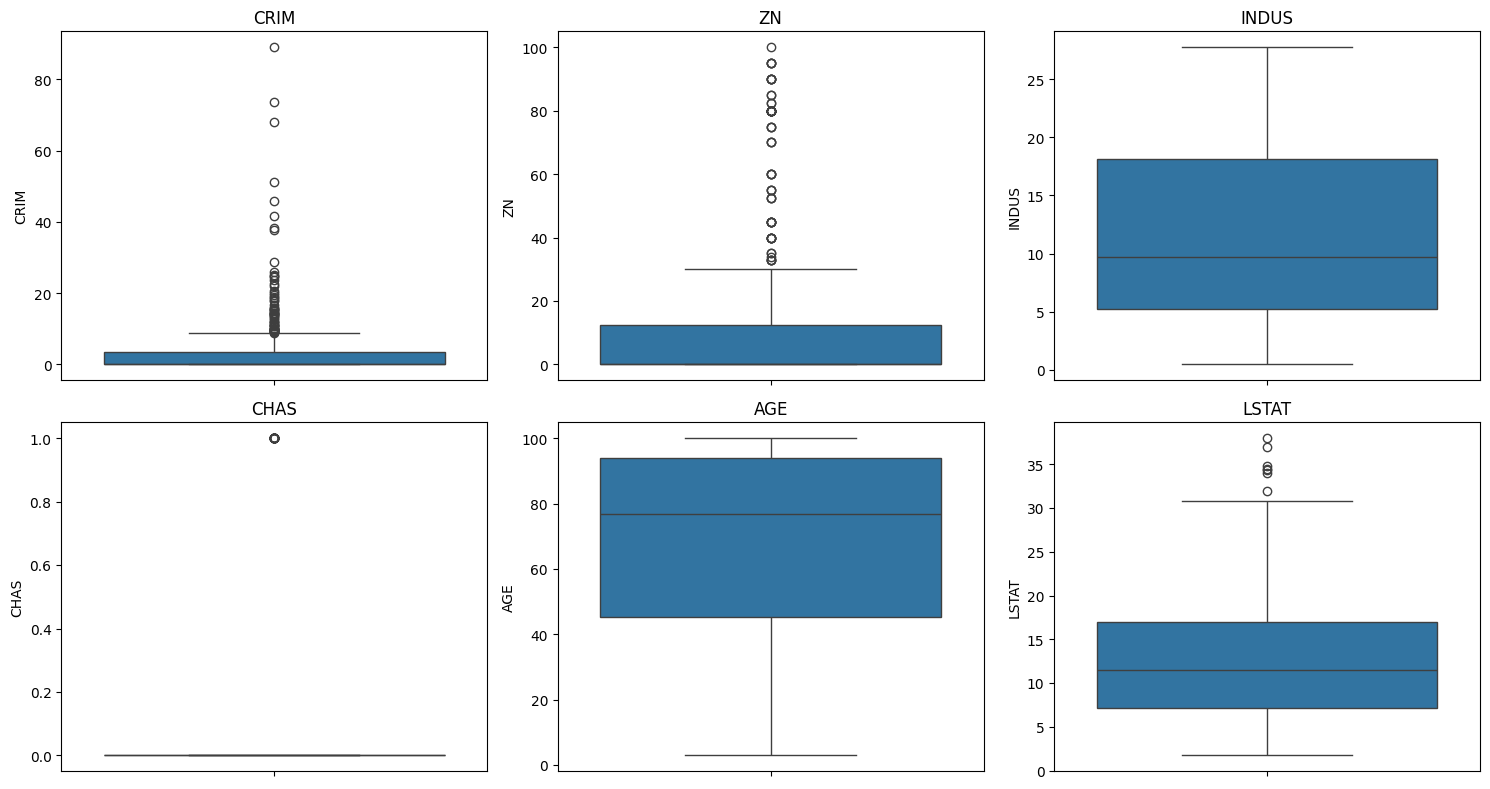

In [15]:
cols = ["CRIM", "ZN", "INDUS", "CHAS", "AGE", "LSTAT"]

plt.figure(figsize=(15,8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [16]:
df["CRIM"].fillna(df["CRIM"].median(), inplace=True)
df["ZN"].fillna(df["ZN"].median(), inplace=True)
df["INDUS"].fillna(df["INDUS"].median(), inplace=True)

df["CHAS"].fillna(df["CHAS"].mode()[0], inplace=True)

df["AGE"].fillna(df["AGE"].median(), inplace=True)
df["LSTAT"].fillna(df["LSTAT"].median(), inplace=True)

/tmp/ipykernel_833/818214455.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_833/818214455.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[

In [17]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


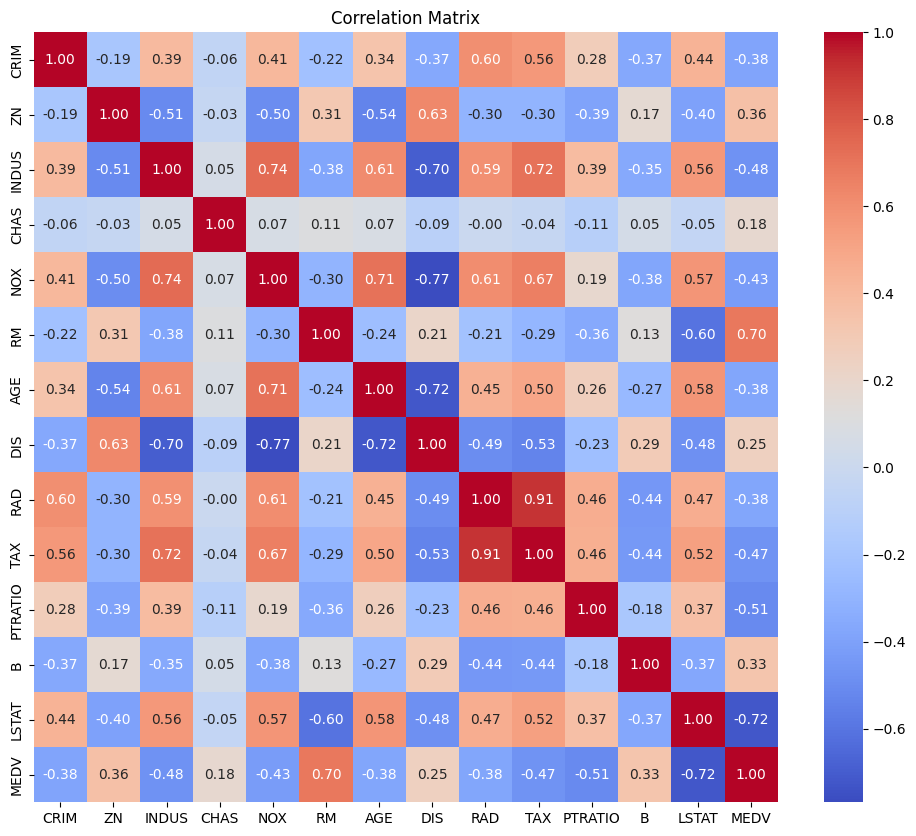

In [18]:
plt.figure(figsize=(12,10))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

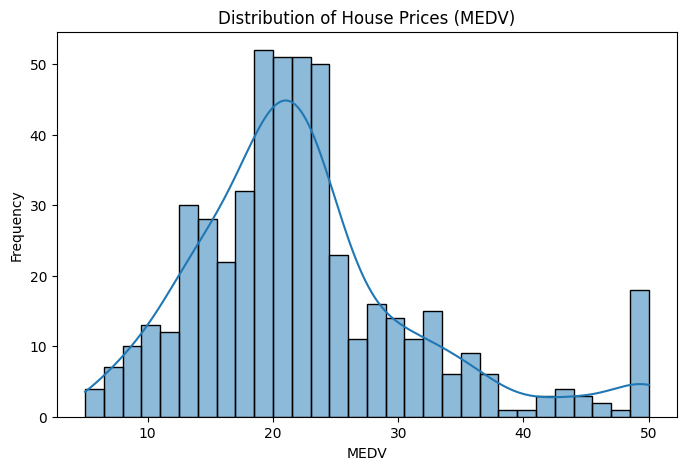

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df["MEDV"], bins=30, kde=True)

plt.title("Distribution of House Prices (MEDV)")
plt.xlabel("MEDV")
plt.ylabel("Frequency")

plt.show()

In [20]:
corr_target = corr["MEDV"].sort_values(ascending=False)
corr_target

,MEDV
MEDV,1.000000
RM,0.695360
ZN,0.362292
B,0.333461
DIS,0.249929
CHAS,0.183844
AGE,-0.377572
RAD,-0.381626
CRIM,-0.383895
NOX,-0.427321


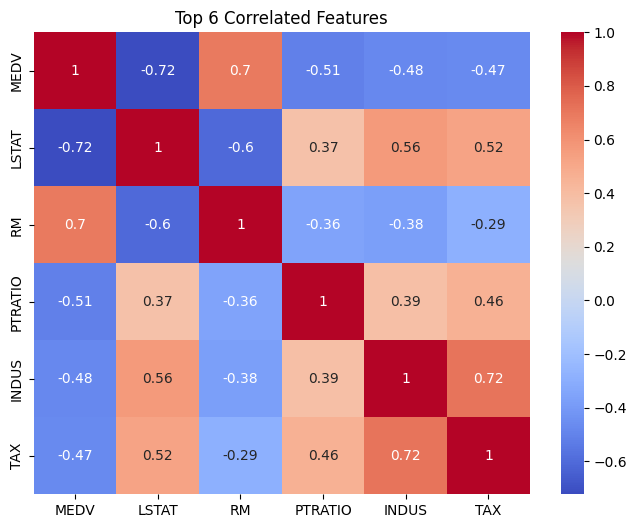

In [21]:
top_features = corr["MEDV"].abs().sort_values(ascending=False).index[:6]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Top 6 Correlated Features")
plt.show()

In [22]:
%whos

Variable        Type             Data/Info
------------------------------------------
ProfileReport   type             <class 'ydata_profiling.p<...>le_report.ProfileReport'>
col             str              LSTAT
cols            list             n=6
corr            DataFrame                     CRIM        <...>461 -0.723093  1.000000  
corr_target     Series           MEDV       1.000000\nRM  <...>ame: MEDV, dtype: float64
desc            DataFrame                    Type  Count  <...>  21.200000    9.197104  
df              DataFrame                CRIM    ZN  INDUS<...>\n[506 rows x 14 columns]
fig             Figure           Figure({\n    'data': [{'<...>: 'Missing Values'}}}\n})
files           module           <module 'google.colab.fil<...>s/google/colab/files.py'>
i               int              6
missing         DataFrame             Column  Missing Valu<...>     MEDV               0
np              module           <module 'numpy' from '/us<...>kages/numpy/__init__.py'>
nu

In [23]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

print(X.shape)
print(y.shape)

(506, 13)
(506,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (404, 13)
X_test : (102, 13)
y_train: (404,)
y_test : (102,)


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
model = LinearRegression()

In [28]:
model.fit(X_train, y_train)

LinearRegression()

In [29]:
y_pred = model.predict(X_test)

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 3.1487373170237607
MSE: 24.999384790103367
RMSE: 4.999938478631849
R2 Score: 0.659101389390351


In [31]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 22.796534653465347
Coefficients: [-0.9934725   0.64824488 -0.17191877  0.83290764 -1.87839285  3.34243906
 -0.49638185 -3.20611875  1.87210088 -1.50273794 -1.98110867  1.10044995
 -3.0909313 ]


In [32]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(results.head(10))

     Actual  Predicted
173    23.6  29.022908
274    32.4  36.516545
491    13.6  14.539302
72     22.8  25.060058
452    16.1  18.396727
76     20.0  23.028883
316    17.8  17.967158
140    14.0  14.582830
471    19.6  22.082804
500    16.8  20.856181
